[如何绘制Nat Commun同款多比较组差异分析火山图？](https://mp.weixin.qq.com/s/Kf63Yvm7OKS5nfbpTFi7KA)

In [4]:
library(ggplot2)
library(tidyverse)
library(ggrepel)

Warning message in system("timedatectl", intern = TRUE):
“running command 'timedatectl' had status 1”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
dt <- read.csv('/data/work/Single-Cell-Pipeline/DEA-Seurat/output/allmarkers_test.csv', header = T)
head(dt)

,X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,arahy.Tifrunner.gnm2.ann2.Ah06g310100,0,2.495758,0.712,0.253,0,1,arahy.Tifrunner.gnm2.ann2.Ah06g310100
2,arahy.Tifrunner.gnm2.ann2.Ah17g200800,0,1.836035,0.674,0.244,0,1,arahy.Tifrunner.gnm2.ann2.Ah17g200800
3,arahy.Tifrunner.gnm2.ann2.Ah04g350700,0,2.954674,0.529,0.115,0,1,arahy.Tifrunner.gnm2.ann2.Ah04g350700
4,arahy.Tifrunner.gnm2.ann2.Ah11g485700,0,2.839624,0.531,0.138,0,1,arahy.Tifrunner.gnm2.ann2.Ah11g485700
5,arahy.Tifrunner.gnm2.ann2.Ah20g052000,0,2.345617,0.520,0.137,0,1,arahy.Tifrunner.gnm2.ann2.Ah20g052000
6,STRG.687,0,2.161031,0.543,0.179,0,1,STRG.687


In [12]:
# 1) 取出所有 cluster 值
cl_vec <- unique(dt$cluster)

# 2) 空表准备接收
sig <- tibble()

# 3) 循环
for (cl in cl_vec) {
  tmp <- dt %>% 
    filter(cluster == cl) %>%          # 当前 cluster
    distinct(gene, .keep_all = TRUE) %>%   # 去重
    top_n(10, abs(avg_log2FC)) %>%      # 取前 10 差异基因
    mutate(cluster = cl)               # 标记来源 cluster
  
  sig <- bind_rows(sig, tmp)
}

# 4) 查看结果
head(sig)
length(sig$gene)

X,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
arahy.Tifrunner.gnm2.ann2.Ah11g444200,4.848911e-181,3.017329,0.085,0.013,2.336739e-176,1,arahy.Tifrunner.gnm2.ann2.Ah11g444200
arahy.Tifrunner.gnm2.ann2.Ah05g388600,7.730224e-121,2.977951,0.046,0.005,3.725272e-116,1,arahy.Tifrunner.gnm2.ann2.Ah05g388600
arahy.Tifrunner.gnm2.ann2.Ah08g147800,4.015672e-79,3.090751,0.029,0.003,1.935193e-74,1,arahy.Tifrunner.gnm2.ann2.Ah08g147800
arahy.Tifrunner.gnm2.ann2.Ah14g358200,6.830903e-72,3.369061,0.026,0.002,3.291881e-67,1,arahy.Tifrunner.gnm2.ann2.Ah14g358200
arahy.Tifrunner.gnm2.ann2.Ah09g035400,5.026846e-48,3.676329,0.016,0.001,2.422487e-43,1,arahy.Tifrunner.gnm2.ann2.Ah09g035400
arahy.Tifrunner.gnm2.ann2.Ah04g401200,4.210229e-38,3.196122,0.014,0.001,2.028952e-33,1,arahy.Tifrunner.gnm2.ann2.Ah04g401200


[1] 100

In [42]:
class(df) 

[1] "function"

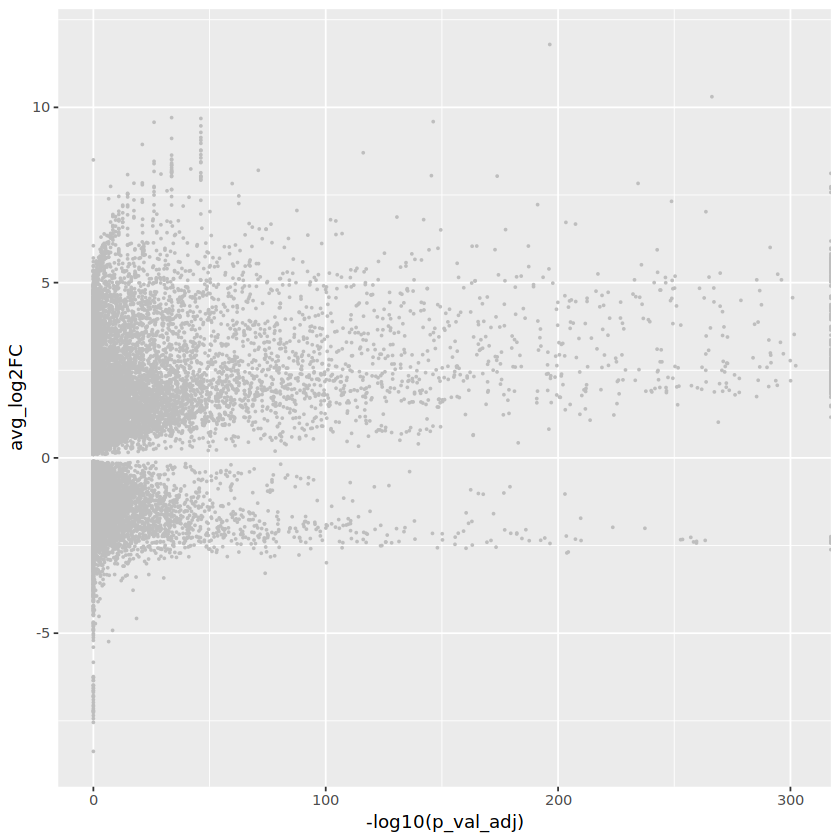

In [68]:
#将neuron_type列转换为因子，用于调整绘图排列顺序：
dt$cluster <- factor(dt$cluster, levels = unique(dt$cluster))

#基础火山图绘制：
p <- ggplot() +
  geom_point(data = dt,
             aes(x = avg_log2FC, y = -log10(p_val_adj)),
             size = 0.4, color = 'grey') +
  coord_flip() #坐标轴翻转
p

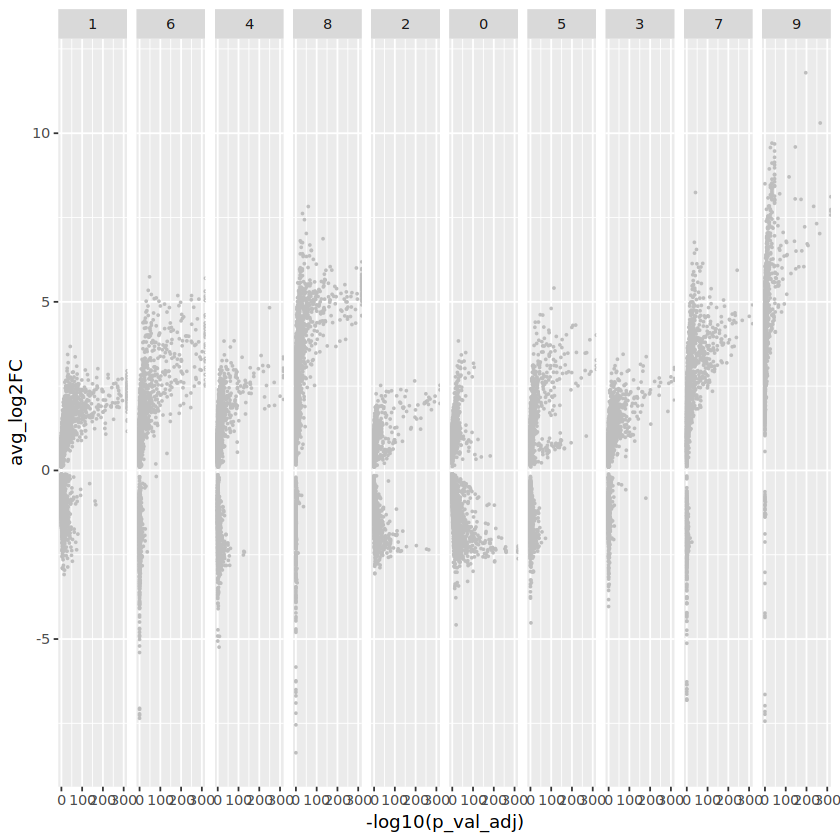

In [69]:
#火山图分面：
p1 <- p + facet_grid(. ~ cluster) #一行多列;如果需要一列多行则var ~ .
p1

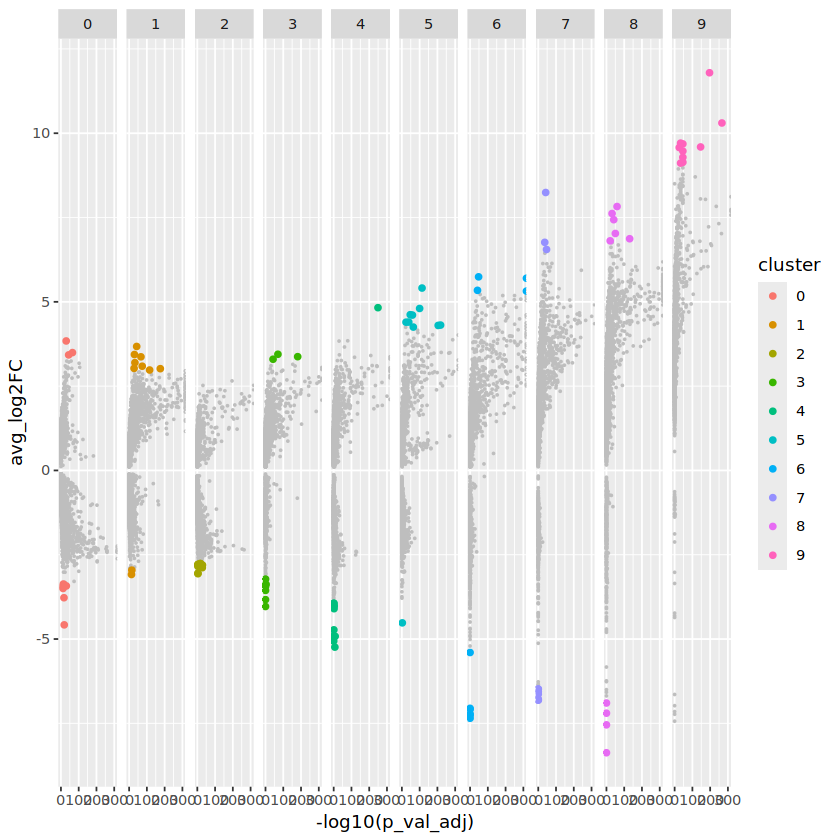

In [70]:
#按cluster列为目标基因上色：
# 1) 先把 sig 的 cluster 转成字符
sig <- sig %>%
  mutate(cluster = as.character(cluster))

# 3) 再画图
p2 <- p1 +
  geom_point(
    data = sig,
    aes(x = avg_log2FC, y = -log10(p_val_adj), color = cluster)
  )
p2

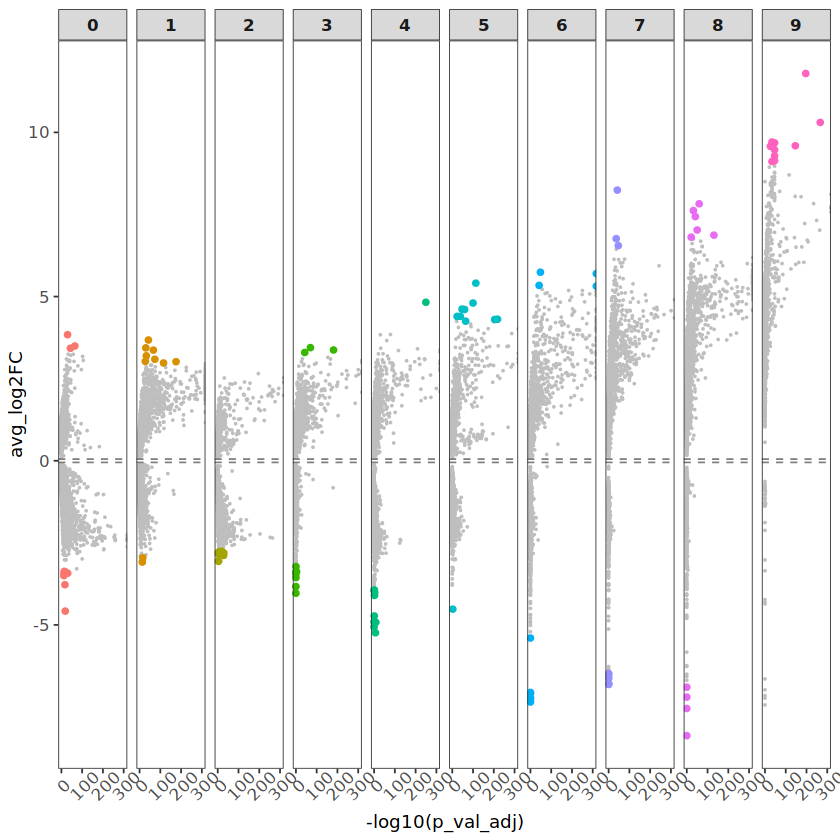

In [76]:
# mycol <- c('#c0322f', '#26aee7', '#96ca39', '#51aa44', '#f7bcd0', 
#            '#f1bd58', '#68c2b2', '#f74141', '#b783b6', '#3565ab')

#参数美化：
p3 <- p2 +
  geom_vline(xintercept = c(-0.05, 0.05), size = 0.5, color = "grey50", lty = 'dashed')+ #添加阈值线
  #scale_color_manual(values = mycol)+ #更改配色
  theme_bw()+
  theme(
    legend.position = 'none', #去掉图例
    panel.grid = element_blank(), #去掉背景网格
    axis.text = element_text(size = 10), #坐标轴标签大小
    axis.text.x = element_text(angle = 45, vjust = 0.8), #x轴标签旋转
    strip.text.x = element_text(size = 10, face = 'bold') #加粗分面标题
  )
p3

Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 10 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 1 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 7 unlabeled data points (too many overlaps). Consider increasing max.overlaps”
Warning message:
“ggrepel: 4 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


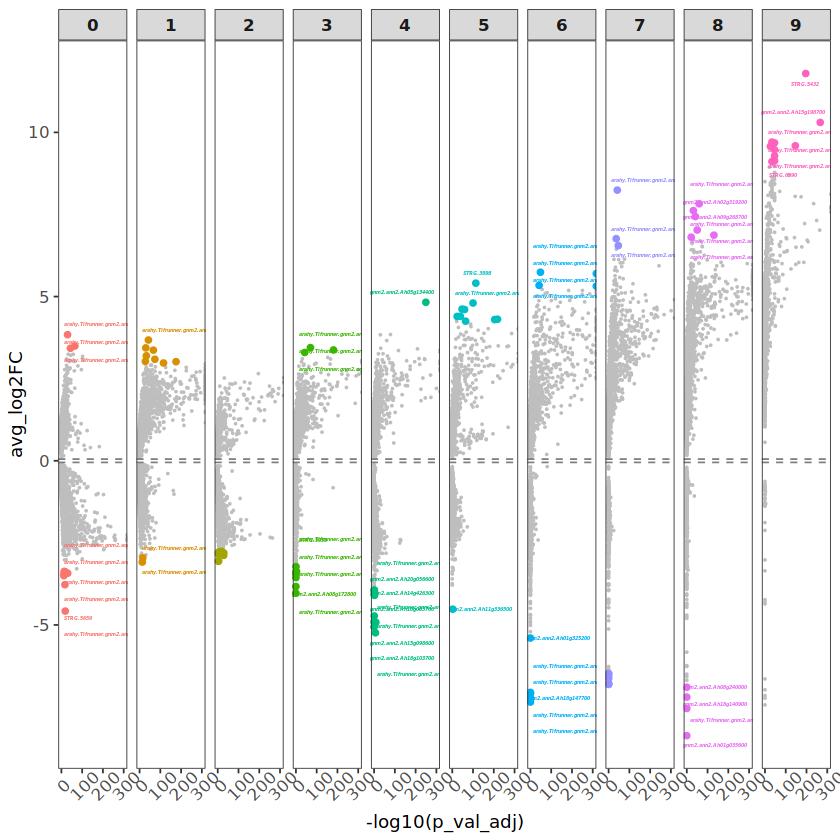

In [77]:
#火山图中添加目标基因id标签:
p4 <- p3 +
    geom_text_repel(data = sig,
                    aes(x = avg_log2FC, y = -log10(p_val_adj), 
                        label = gene, color = cluster),
                    size = 1,fontface = 'bold.italic'
                   )
p4

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


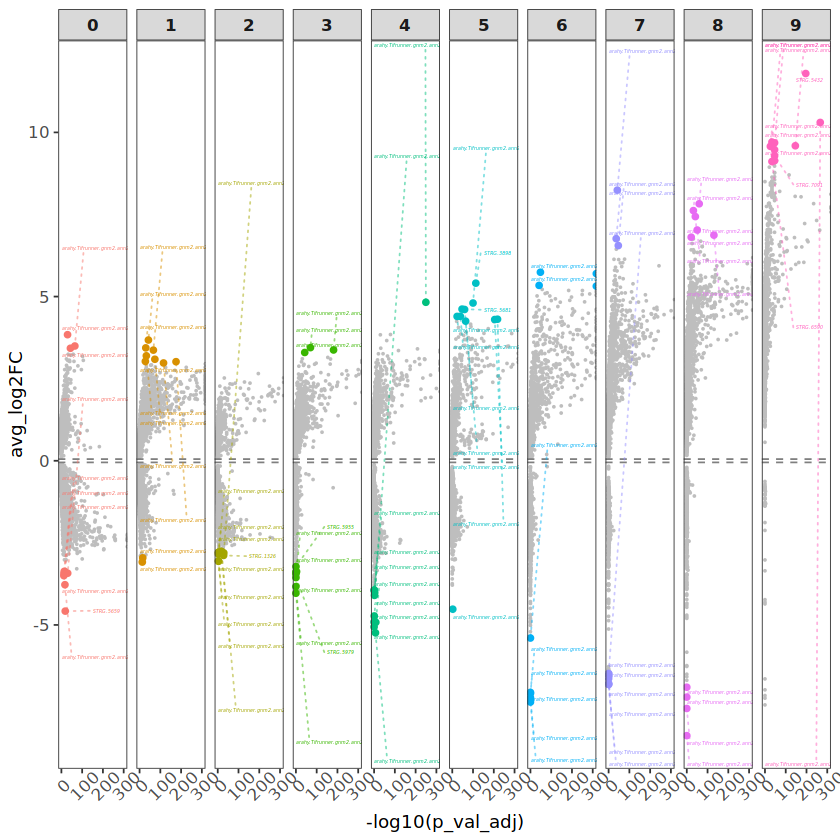

In [74]:
#标签调整：使用对齐式id标签：
p5 <- p3 +
    geom_text_repel(
        data = sig, 
        aes(x = avg_log2FC, y = -log10(p_val_adj), 
            label = gene, color = cluster),
        fontface = 'italic',
        seed = 233,
        size = 1,
        min.segment.length = 0, #始终为标签添加指引线段；若不想添加线段，则改为Inf
        force = 12, #重叠标签间的排斥力
        force_pull = 2, #标签和数据点间的吸引力
        box.padding = 0.1, #标签周边填充量，默认单位为行
        max.overlaps = Inf, ##排斥重叠过多标签，设置为Inf则可以保持始终显示所有标签
        segment.linetype = 3, #线段类型,1为实线,2-6为不同类型虚线
        segment.alpha = 0.5, #线段不透明度
        nudge_y = 150 - (-log10(sig$p_val_adj)), #标签x轴起始位置
        direction = "y", #按y轴调整标签位置方向，若想水平对齐则为x
        hjust = 0 #0右对齐，1左对齐，0.5居中
    )
p5

In [80]:
pdf("volcano.pdf", width=15, height = 5)
print(p5)
dev.off()

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


png 
  2